# PR #5452: CPU chi-square workspace allocation on len

## tl;dr

**The input that motivates this PR is `complex64`, and that is the main benchmark here.** The PR keeps the input type but promotes its intermediate arithmetic and workspace to double precision. For `complex64` inputs of one to four million samples on len, direct NumPy allocation is within **1%** of a controlled one-block C `malloc`. At 4,096 samples it is **3.6–3.9% slower**, about a microsecond per call. Reusing a NumPy workspace saves **0.8–1.8%** only in that short case. These measurements support keeping the current direct allocation. `complex128` results appear separately as a performance control, not as the motivating precision case.

This notebook analyses a completed, CPU-pinned run on **len** on 23 September 2026. The raw result tables, Cython sources, build script and benchmark driver are archived under [`allocation/`](allocation/). The current PR source is [`8c96aff`](https://github.com/gwastro/pycbc/pull/5452/commits/8c96affb842687557fbb5b26f293e03b1e6b9ba0); the motivating [review question](https://github.com/gwastro/pycbc/pull/5452#discussion_r4082180937) asks whether allocation should use C `malloc` or caching.

## Context & methods

`shift_sum` runs PyCBC's CPU selected-time chi-square kernel. Its correlation input is often `complex64`: that is where repeated float32 arithmetic loses precision. The PR **still accepts `complex64` input** but uses double working arithmetic. Its nine `float64` work rows are allocated with one `numpy.empty` call. The main question is whether that allocation slows the corrected `complex64` path. The workspace has shape `(9, max(number_of_selected_points, 1))`: for the 1/2/5-point cases here, it contains only **72/144/360 bytes** of `float64` values. The 4,096 to 2²² sample labels below are **correlation lengths**, which control the amount of kernel work, not the workspace allocation size. We compare it with:

| Variant | Meaning |
| --- | --- |
| `numpy` | Current PR head: new NumPy workspace on every call |
| `malloc1` | Diagnostic copy of the PR head with **only** the workspace replaced by one checked contiguous C `malloc`/`free` block |
| `cache` | Prior PR commit with a reused module-global NumPy workspace |
| `malloc` | Earlier PR commit using eight C allocations and a different accumulator representation; context only |
| `base` | Upstream before the double-working-precision patch; context only |

### Key assumptions

* The benchmark times only `shift_sum`; input construction and compilation are excluded. It does include Python call and result allocation overhead.
* Four input shapes: 4,096 synthetic samples; 2²⁰ synthetic samples; 2²⁰ recorded H1 correlation samples with its captured bins; and 2²² synthetic samples. Each uses 16 bins and 1/2/5 selected points. The analysis leads with complex64; complex128 is retained as a control and archived in the same CSVs.
* Nine interleaved batches per case, 30 calls per batch for 4,096 samples and two per batch otherwise. The reported ratio is the **median of paired batch ratios**, not a ratio of displayed medians. Input order is seeded; variant order is shuffled per batch. CPU affinity was pinned to logical CPU 56 on len.
* All three double-precision alternatives were checked against the PR head at `rtol=1e-12`, `atol=1e-10` before timing. The historical `base` kernel has intentionally different arithmetic and is not subject to this equality check.
* The cached variant has shared module-global state. This run measures sequential calls only; it does not establish concurrency safety.


## Data

The following files are committed with this notebook. `len_` files are the untouched outputs of the completed run. The driver writes fresh, unprefixed output files when rerun.

In [1]:
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

asset = Path('allocation')
manifest = json.loads((asset / 'manifest.json').read_text())
environment = json.loads((asset / 'len_environment.json').read_text())
timings = pd.read_csv(asset / 'len_timings.csv')
ratios = pd.read_csv(asset / 'len_paired_ratios.csv')

for filename, expected in manifest['sha256'].items():
    actual = hashlib.sha256((asset / filename).read_bytes()).hexdigest()
    assert actual == expected, filename
for filename, expected in manifest['len_result_sha256'].items():
    assert hashlib.sha256((asset / filename).read_bytes()).hexdigest() == expected, filename
capture = Path('../data/point-input-05.npz')
assert hashlib.sha256(capture.read_bytes()).hexdigest() == manifest['captured_input']['sha256']
assert len(timings) == 4 * 2 * 3 * 5
assert len(ratios) == 4 * 2 * 3
assert not timings.duplicated(['shape', 'dtype', 'npoints', 'variant']).any()
assert not ratios.duplicated(['shape', 'dtype', 'npoints']).any()
assert (timings['median_ms'] > 0).all()
print('Recorded host:', manifest['len_run']['host'])
print('Platform:', environment['platform'])
print('Python:', environment['python'].split(' | ')[0], 'NumPy:', environment['numpy'])
print('Compiler:', environment['compiler'])
print('Validated:', len(timings), 'timing rows;', len(ratios), 'paired comparisons; source and capture SHA256s')

Recorded host: len
Platform: Linux-6.8.0-138-generic-x86_64-with-glibc2.39
Python: 3.11.9 NumPy: 1.26.4
Compiler: c++ (Ubuntu 12.4.0-2ubuntu1~24.04.1) 12.4.0
Validated: 120 timing rows; 24 paired comparisons; source and capture SHA256s


## Results

### Allocator overhead for `complex64` input

Below, `100 × (NumPy time / alternative time − 1)` is the percentage by which the current PR variant is slower. Negative values mean NumPy was faster. Each cell is one case's paired-batch median; the colour scale is shared across panels. This is the input path the precision fix is intended to address.

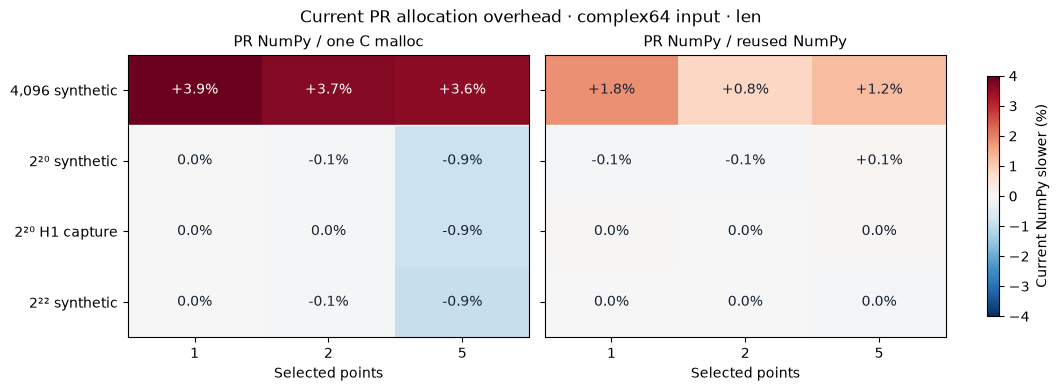

In [2]:
shape_order = ['short', 'uniform', 'captured', 'wide']
shape_labels = ['4,096 synthetic', '2²⁰ synthetic', '2²⁰ H1 capture', '2²² synthetic']
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), sharex=True, sharey=True,
                         constrained_layout=True)
for ax, (ratio_column, title) in zip(axes, [
    ('numpy_vs_malloc1', 'PR NumPy / one C malloc'),
    ('numpy_vs_cache', 'PR NumPy / reused NumPy')]):
    data = (ratios[ratios['dtype'] == 'complex64']
            .pivot(index='shape', columns='npoints', values=ratio_column)
            .reindex(index=shape_order, columns=[1, 2, 5]))
    percent = 100 * (data.to_numpy() - 1)
    im = ax.imshow(percent, cmap='RdBu_r', vmin=-4, vmax=4, aspect='auto')
    for y in range(4):
        for x in range(3):
            label = '0.0%' if abs(percent[y, x]) < 0.05 else f'{percent[y, x]:+.1f}%'
            ax.text(x, y, label, ha='center', va='center', fontsize=10,
                    color='white' if abs(percent[y, x]) >= 3 else '#172333')
    ax.set_title(title, fontsize=11)
    ax.set_xticks(range(3), ['1', '2', '5'])
    ax.set_yticks(range(4), shape_labels)
    ax.set_xlabel('Selected points')
    ax.axhline(0.5, color='white', linewidth=1)
fig.suptitle('Current PR allocation overhead · complex64 input · len', fontsize=12)
fig.colorbar(im, ax=axes, label='Current NumPy slower (%)', shrink=0.85)
plt.show()

For the three larger shapes, the current NumPy allocation is within **1%** of the single C allocation in every `complex64` case. At 4,096 samples, the NumPy overhead is **3.6–3.9%**, about a microsecond. The reused NumPy workspace is close to the current variant at all larger sizes; its short-input benefit is **0.8–1.8%**.

In [3]:
summary = (ratios[ratios['dtype'] == 'complex64']
           .groupby('shape', sort=False)[['numpy_vs_malloc1', 'numpy_vs_cache']]
           .agg(['min', 'median', 'max'])
           .reindex(shape_order))
summary.columns = [f'{name.replace("numpy_vs_", "NumPy / ")} {stat}'
                   for name, stat in summary.columns]
display(summary.round(4))

,NumPy / malloc1 min,NumPy / malloc1 median,NumPy / malloc1 max,NumPy / cache min,NumPy / cache median,NumPy / cache max
shape,,,,,,
short,1.0359,1.0367,1.0391,1.0084,1.0122,1.0183
uniform,0.9913,0.9992,1.0000,0.9992,0.9994,1.0009
captured,0.9914,0.9996,1.0003,0.9998,1.0003,1.0005
wide,0.9908,0.9991,1.0002,0.9995,0.9998,1.0002


### `complex128` control

The input type also remains `complex128` when supplied. We timed it to check whether the allocator conclusion is peculiar to `complex64`, but its numerical behaviour is not the reason for this PR. The complete per-case results remain in the archived CSVs.

In [4]:
control = (ratios[ratios['dtype'] == 'complex128']
           .groupby('shape', sort=False)[['numpy_vs_malloc1', 'numpy_vs_cache']]
           .agg(['min', 'max'])
           .reindex(shape_order))
control.columns = [f'{name.replace("numpy_vs_", "NumPy / ")} {stat}'
                   for name, stat in control.columns]
display(control.round(4))

,NumPy / malloc1 min,NumPy / malloc1 max,NumPy / cache min,NumPy / cache max
shape,,,,
short,1.0502,1.0735,1.0122,1.0258
uniform,1.0002,1.0043,0.9981,1.0030
captured,1.0011,1.0043,1.0003,1.0029
wide,0.9998,1.0042,1.0001,1.0026


### Absolute cost on the captured H1 layout

This view puts the allocator comparisons beside the total double-arithmetic cost. Bars show medians of nine batch means for complex64 and five selected points; whiskers span the 25th–75th batch percentiles, **not confidence intervals**.

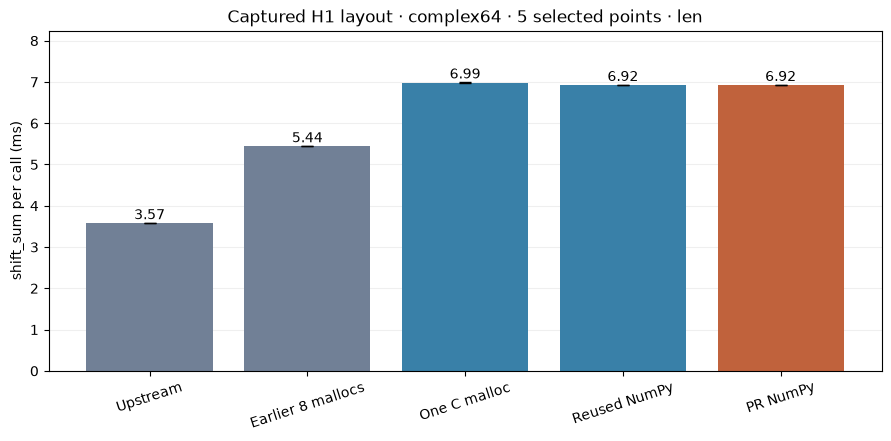

,median_ms,q25_ms,q75_ms
variant,,,
base,3.5749,3.5738,3.5780
malloc,5.4387,5.4364,5.4392
malloc1,6.9851,6.9846,6.9869
cache,6.9237,6.9203,6.9256
numpy,6.9242,6.9204,6.9302


In [5]:
subset = (timings[(timings['shape'] == 'captured') &
                  (timings['dtype'] == 'complex64') &
                  (timings['npoints'] == 5)]
          .set_index('variant')
          .reindex(['base', 'malloc', 'malloc1', 'cache', 'numpy']))
labels = ['Upstream', 'Earlier 8 mallocs', 'One C malloc', 'Reused NumPy', 'PR NumPy']
colors = ['#718096', '#718096', '#3980a8', '#3980a8', '#c0623c']
fig, ax = plt.subplots(figsize=(8.8, 4.3), constrained_layout=True)
y = subset['median_ms'].to_numpy()
low = y - subset['q25_ms'].to_numpy()
high = subset['q75_ms'].to_numpy() - y
ax.bar(labels, y, color=colors, yerr=np.vstack([low, high]), capsize=4)
for idx, value in enumerate(y):
    ax.text(idx, value + 0.10, f'{value:.2f}', ha='center', fontsize=10)
ax.set_ylim(0, max(y) * 1.18)
ax.set_ylabel('shift_sum per call (ms)')
ax.set_title('Captured H1 layout · complex64 · 5 selected points · len')
ax.grid(axis='y', alpha=0.2)
ax.set_axisbelow(True)
ax.tick_params(axis='x', rotation=18)
plt.show()
display(subset[['median_ms', 'q25_ms', 'q75_ms']].round(4))

The PR NumPy median is **6.92 ms**, compared with **6.99 ms** for the controlled single C allocation and **6.92 ms** for the cache. Upstream is **3.57 ms**, so the overall precision patch is about **1.94×** upstream for this captured five-point case. The old eight-malloc revision differs in arithmetic layout and cannot be used to attribute the runtime gap to allocation. This benchmark does not isolate the causes of the precision patch's total runtime change.

## Reproduce on len

From this repository's `examples/numerics/cpu_chisq_fixes/allocation/` directory, in a Python environment with PyCBC, NumPy 1.26.4, Cython, and a C++ compiler:

```bash
python setup.py build_ext --inplace
taskset -c 56 python bench.py > rerun.log 2>&1
```

`setup.py` uses `-O3 -w -ffast-math -ffinite-math-only -msse4.2 -fopenmp`, matching the archived run. The driver loads the captured input from `../../data/point-input-05.npz`, checks numerical agreement, and writes `timings.csv`, `ratios.csv`, and `environment.json` next to itself. These new files are separate from the archived `len_` results. Different CPU load, runtime versions, or affinity can change small ratios. `manifest.json` records exact source commit IDs and SHA256 hashes; `malloc1` is explicitly a scratch diagnostic variant, not a PR commit.

## Takeaways

For the relevant `complex64` input, the len results show no material benefit from replacing the current one-allocation NumPy workspace with a one-block C allocation for million-sample inputs. The `complex128` control points to the same conclusion at those sizes. Caching barely changes the long cases and introduces shared state that would need a separate concurrency review. The short-input overhead is measurable but about a microsecond. The larger runtime change relative to upstream is in the precision patch as a whole and needs a separate performance decision if search throughput is the concern.